In [2]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
from pathlib import Path

In [4]:
DATASET_PATH = Path(
    "/kaggle/input/datasets/satishchandra9618/face-mask-data/Face_mask_ds"
)

MASK_DIR = DATASET_PATH / "Mask"
NO_MASK_DIR = DATASET_PATH / "No_mask"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

mask_files = sorted(
    p for p in MASK_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
)

no_mask_files = sorted(
    p for p in NO_MASK_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
)

print("Dataset path:", DATASET_PATH)
print()
print("Mask images   :", len(mask_files))
print("No-mask images:", len(no_mask_files))
print("Total images  :", len(mask_files) + len(no_mask_files))

Dataset path: /kaggle/input/datasets/satishchandra9618/face-mask-data/Face_mask_ds

Mask images   : 18197
No-mask images: 17513
Total images  : 35710


In [5]:
# Combine all image paths
all_files = mask_files + no_mask_files

# Labels:
# Mask    = 1
# No_mask = 0
all_labels = (
    [1] * len(mask_files) +
    [0] * len(no_mask_files)
)

print("Total images:", len(all_files))
print("Total labels:", len(all_labels))

Total images: 35710
Total labels: 35710


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=42
)

print("Training:", len(train_files))
print("Temporary:", len(temp_files))

Training: 28568
Temporary: 7142


In [8]:
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Train      :", len(train_files))
print("Validation :", len(val_files))
print("Test       :", len(test_files))

Train      : 28568
Validation : 3571
Test       : 3571


In [9]:
def count_classes(labels):
    labels = np.array(labels)

    return {
        "Mask": np.sum(labels == 1),
        "No_mask": np.sum(labels == 0)
    }


print("TRAIN")
print(count_classes(train_labels))

print("\nVALIDATION")
print(count_classes(val_labels))

print("\nTEST")
print(count_classes(test_labels))

TRAIN
{'Mask': np.int64(14558), 'No_mask': np.int64(14010)}

VALIDATION
{'Mask': np.int64(1820), 'No_mask': np.int64(1751)}

TEST
{'Mask': np.int64(1819), 'No_mask': np.int64(1752)}


In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, tf.cast(label, tf.float32)

In [11]:
# Convert file paths to strings
train_paths = [str(p) for p in train_files]
val_paths = [str(p) for p in val_files]
test_paths = [str(p) for p in test_files]

# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

print("Datasets created successfully!")

Datasets created successfully!


I0000 00:00:1789754019.334790    1141 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789754019.337921    1141 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

print("Image preprocessing connected!")

Image preprocessing connected!


In [13]:
train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("TensorFlow input pipeline ready!")

TensorFlow input pipeline ready!


In [14]:
print("TRAIN")
print("Images:", len(train_paths))
print("Labels:", len(train_labels))

print("\nVALIDATION")
print("Images:", len(val_paths))
print("Labels:", len(val_labels))

print("\nTEST")
print("Images:", len(test_paths))
print("Labels:", len(test_labels))

print("\nClass distribution:")
print("Train:", np.bincount(train_labels))
print("Validation:", np.bincount(val_labels))
print("Test:", np.bincount(test_labels))

TRAIN
Images: 28568
Labels: 28568

VALIDATION
Images: 3571
Labels: 3571

TEST
Images: 3571
Labels: 3571

Class distribution:
Train: [14010 14558]
Validation: [1751 1820]
Test: [1752 1819]


In [15]:
print("Dataset path:", DATASET_PATH)
print("Mask folder exists:", MASK_DIR.exists())
print("No_mask folder exists:", NO_MASK_DIR.exists())

print("\nMask images:", len(list(MASK_DIR.iterdir())))
print("No_mask images:", len(list(NO_MASK_DIR.iterdir())))

Dataset path: /kaggle/input/datasets/satishchandra9618/face-mask-data/Face_mask_ds
Mask folder exists: True
No_mask folder exists: True

Mask images: 18197
No_mask images: 17513


# **MODEL BUILDING AND EVALUATION**

In [16]:
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Batch size: 32
Epochs: 10
Learning rate: 0.001


In [17]:
def build_pretrained_model(base_model):
    
    # Freeze the pretrained backbone for screening
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(
            128,
            activation="relu"
        ),

        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Pretrained model builder ready!")

Pretrained model builder ready!


# 1.RESNET

In [23]:
resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_model = build_pretrained_model(resnet_base)

print("ResNet50 loaded successfully!")
print("Trainable layers:", sum(layer.trainable for layer in resnet_model.layers))

ResNet50 loaded successfully!
Trainable layers: 4


In [20]:
start_time = time.time()

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

resnet_time = time.time() - start_time

print(f"\nResNet50 training time: {resnet_time / 60:.2f} minutes")

Epoch 1/10
  2/893 ━━━━━━━━━━━━━━━━━━━━ 1:24 95ms/step - accuracy: 0.5938 - loss: 0.7094    

I0000 00:00:1789746845.258750     148 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


893/893 ━━━━━━━━━━━━━━━━━━━━ 284s 124ms/step - accuracy: 0.7162 - loss: 0.5492 - val_accuracy: 0.7373 - val_loss: 0.4720
Epoch 2/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 206s 105ms/step - accuracy: 0.8045 - loss: 0.4249 - val_accuracy: 0.8538 - val_loss: 0.3617
Epoch 3/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 212s 106ms/step - accuracy: 0.8210 - loss: 0.3969 - val_accuracy: 0.8213 - val_loss: 0.3876
Epoch 4/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 217s 106ms/step - accuracy: 0.8399 - loss: 0.3607 - val_accuracy: 0.8883 - val_loss: 0.2933
Epoch 5/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 217s 108ms/step - accuracy: 0.8568 - loss: 0.3364 - val_accuracy: 0.8751 - val_loss: 0.2938
Epoch 6/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 237s 110ms/step - accuracy: 0.8675 - loss: 0.3155 - val_accuracy: 0.9023 - val_loss: 0.2599
Epoch 7/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 236s 107ms/step - accuracy: 0.8717 - loss: 0.3078 - val_accuracy: 0.8824 - val_loss: 0.2827
Epoch 8/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 214s 105ms/step - accuracy: 0.8746 - loss: 0.29

# 2) MobileNet

In [25]:
# MobileNetV2

mobilenet_base = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_model = build_pretrained_model(mobilenet_base)

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


In [22]:
start_time = time.time()

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

mobilenet_time = time.time() - start_time

print(
    f"\nMobileNetV2 training time: "
    f"{mobilenet_time / 60:.2f} minutes"
)

Epoch 1/10


2026-09-18 16:34:01.708330: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:34:01.844748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


891/893 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9815 - loss: 0.0444

2026-09-18 16:34:42.153084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:34:42.289844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


893/893 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9815 - loss: 0.0443

2026-09-18 16:35:08.456669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:35:08.593701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


893/893 ━━━━━━━━━━━━━━━━━━━━ 238s 73ms/step - accuracy: 0.9927 - loss: 0.0188 - val_accuracy: 0.9961 - val_loss: 0.0169
Epoch 2/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 151s 42ms/step - accuracy: 0.9976 - loss: 0.0071 - val_accuracy: 0.9978 - val_loss: 0.0112
Epoch 3/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 144s 41ms/step - accuracy: 0.9988 - loss: 0.0041 - val_accuracy: 0.9964 - val_loss: 0.0198
Epoch 4/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 141s 41ms/step - accuracy: 0.9986 - loss: 0.0036 - val_accuracy: 0.9969 - val_loss: 0.0133
Epoch 5/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 153s 42ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9969 - val_loss: 0.0115
Epoch 6/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 165s 45ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9961 - val_loss: 0.0131
Epoch 7/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 157s 43ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9969 - val_loss: 0.0128
Epoch 8/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 165s 44ms/step - accuracy: 0.9991 - loss: 0.0030 - val

# 3) EfficientNet

In [26]:
# EfficientNetB0

efficientnet_base = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

efficientnet_model = build_pretrained_model(efficientnet_base)

print("EfficientNetB0 loaded successfully!")

EfficientNetB0 loaded successfully!


In [24]:
start_time = time.time()

history_efficientnet = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

efficientnet_time = time.time() - start_time

print(
    f"\nEfficientNetB0 training time: "
    f"{efficientnet_time / 60:.2f} minutes"
)

Epoch 1/10


2026-09-18 17:02:21.856047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:02:21.999377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:02:22.360071: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:02:22.501490: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:02:23.271266: E external/local_xla/xla/stream_

892/893 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5126 - loss: 0.6970

2026-09-18 17:03:07.522930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:07.664442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:08.008103: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:08.149865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:08.927979: E external/local_xla/xla/stream_

893/893 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5126 - loss: 0.6970

2026-09-18 17:03:35.086837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:35.227435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:35.562622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:35.704125: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 17:03:36.535944: E external/local_xla/xla/stream_

893/893 ━━━━━━━━━━━━━━━━━━━━ 228s 78ms/step - accuracy: 0.5117 - loss: 0.6942 - val_accuracy: 0.5097 - val_loss: 0.6930
Epoch 2/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 154s 48ms/step - accuracy: 0.5096 - loss: 0.6930 - val_accuracy: 0.5097 - val_loss: 0.6930
Epoch 3/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 149s 48ms/step - accuracy: 0.5096 - loss: 0.6930 - val_accuracy: 0.5097 - val_loss: 0.6930
Epoch 4/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 152s 49ms/step - accuracy: 0.5096 - loss: 0.6930 - val_accuracy: 0.5097 - val_loss: 0.6930
Epoch 5/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 174s 50ms/step - accuracy: 0.5096 - loss: 0.6930 - val_accuracy: 0.5097 - val_loss: 0.6930
Epoch 6/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 178s 51ms/step - accuracy: 0.5094 - loss: 0.6930 - val_accuracy: 0.5097 - val_loss: 0.6930
Epoch 7/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 176s 51ms/step - accuracy: 0.5096 - loss: 0.6930 - val_accuracy: 0.5097 - val_loss: 0.6930
Epoch 8/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 175s 51ms/step - accuracy: 0.5096 - loss: 0.6930 - val

# 4) DenseNet

In [27]:
# DenseNet121

densenet_base = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

densenet_model = build_pretrained_model(densenet_base)

print("DenseNet121 loaded successfully!")

DenseNet121 loaded successfully!


In [19]:
start_time = time.time()

history_densenet = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

densenet_time = time.time() - start_time

print(
    f"\nDenseNet121 training time: "
    f"{densenet_time / 60:.2f} minutes"
)

Epoch 1/10
  1/893 ━━━━━━━━━━━━━━━━━━━━ 42:20:21 171s/step - accuracy: 0.4062 - loss: 1.0869

I0000 00:00:1789754214.726775    1186 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


893/893 ━━━━━━━━━━━━━━━━━━━━ 290s 133ms/step - accuracy: 0.9912 - loss: 0.0249 - val_accuracy: 0.9975 - val_loss: 0.0106
Epoch 2/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 193s 90ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 0.9950 - val_loss: 0.0109
Epoch 3/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 185s 90ms/step - accuracy: 0.9977 - loss: 0.0066 - val_accuracy: 0.9980 - val_loss: 0.0056
Epoch 4/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 184s 91ms/step - accuracy: 0.9986 - loss: 0.0042 - val_accuracy: 0.9972 - val_loss: 0.0064
Epoch 5/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 211s 93ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.9986 - val_loss: 0.0054
Epoch 6/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 214s 93ms/step - accuracy: 0.9994 - loss: 0.0018 - val_accuracy: 0.9989 - val_loss: 0.0035
Epoch 7/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 215s 93ms/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 0.9989 - val_loss: 0.0041
Epoch 8/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 213s 93ms/step - accuracy: 0.9993 - loss: 0.0026 - va

# 5) Inception

In [28]:
# InceptionV3

inception_base = tf.keras.applications.InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

inception_model = build_pretrained_model(inception_base)

print("InceptionV3 loaded successfully!")

InceptionV3 loaded successfully!


In [21]:
start_time = time.time()

history_inception = inception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

inception_time = time.time() - start_time

print(
    f"\nInceptionV3 training time: "
    f"{inception_time / 60:.2f} minutes"
)

Epoch 1/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 232s 101ms/step - accuracy: 0.9912 - loss: 0.0233 - val_accuracy: 0.9958 - val_loss: 0.0165
Epoch 2/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 181s 78ms/step - accuracy: 0.9971 - loss: 0.0089 - val_accuracy: 0.9978 - val_loss: 0.0094
Epoch 3/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 174s 78ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9980 - val_loss: 0.0098
Epoch 4/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 175s 78ms/step - accuracy: 0.9976 - loss: 0.0073 - val_accuracy: 0.9980 - val_loss: 0.0122
Epoch 5/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 176s 78ms/step - accuracy: 0.9989 - loss: 0.0033 - val_accuracy: 0.9983 - val_loss: 0.0112
Epoch 6/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 178s 78ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9947 - val_loss: 0.0275
Epoch 7/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 189s 80ms/step - accuracy: 0.9986 - loss: 0.0047 - val_accuracy: 0.9975 - val_loss: 0.0126
Epoch 8/10
893/893 ━━━━━━━━━━━━━━━━━━━━ 202s 80ms/step - accuracy: 0.9989 - loss: 

# **EVALUATION**

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================================
# MODEL LIST
# ==========================================

models = [
    ("ResNet50", resnet_model),
    ("MobileNetV2", mobilenet_model),
    ("EfficientNetB0", efficientnet_model),
    ("DenseNet121", densenet_model),
    ("InceptionV3", inception_model)
]

# ==========================================
# TRUE LABELS
# ==========================================

y_true = np.array(test_labels).astype(int)

results = []

# ==========================================
# EVALUATE EACH MODEL
# ==========================================

for name, model in models:

    print("Evaluating:", name)

    predictions = model.predict(
        test_ds,
        verbose=0
    )

    y_prob = predictions.reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred) * 100,
        "Recall": recall_score(y_true, y_pred) * 100,
        "F1-Score": f1_score(y_true, y_pred) * 100,
        "ROC-AUC": roc_auc_score(y_true, y_prob) * 100
    })

# ==========================================
# CREATE DATAFRAME
# ==========================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 75)
print("PRETRAINED MODEL COMPARISON")
print("=" * 75)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)

Evaluating: ResNet50
Evaluating: MobileNetV2
Evaluating: EfficientNetB0
Evaluating: DenseNet121
Evaluating: InceptionV3


PRETRAINED MODEL COMPARISON
         Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      ResNet50     48.56      32.00    0.88      1.71    30.64
   MobileNetV2     38.78      40.35   42.17     41.24    33.26
EfficientNetB0     50.94      50.94  100.00     67.50    39.53
   DenseNet121     50.66      50.81   98.79     67.10    43.88
   InceptionV3     51.27      51.57   71.25     59.83    49.59


In [32]:
import matplotlib.pyplot as plt

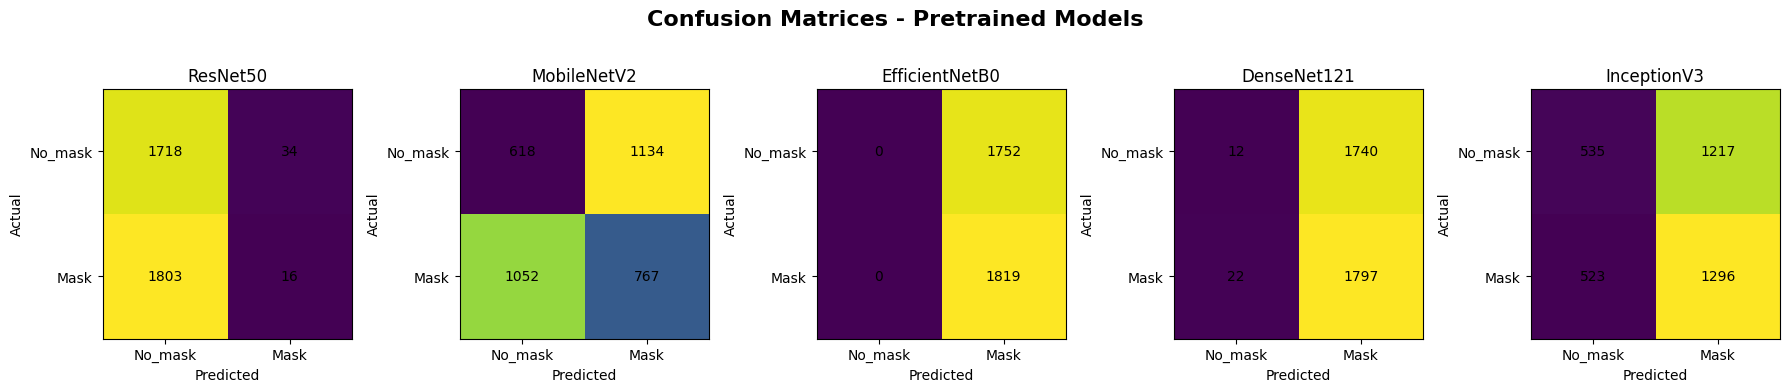

In [33]:
# ==========================================
# CONFUSION MATRICES
# ==========================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(18, 4)
)

for ax, (name, model) in zip(axes, models.items()):

    y_prob = model.predict(
        test_ds,
        verbose=0
    ).ravel()

    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    ax.imshow(cm)

    ax.set_title(name)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["No_mask", "Mask"])
    ax.set_yticklabels(["No_mask", "Mask"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.suptitle(
    "Confusion Matrices - Pretrained Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()